In [5]:
# 1. Imports
import os
import pickle
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, ParameterGrid
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm
import hashlib

# 2. Create cache directory
os.makedirs('./cache', exist_ok=True)

# 3. Load & prepare data
train_data_encoded = pd.read_csv('../data/train_encoded.csv')
X = train_data_encoded.drop('y', axis=1).values
y = train_data_encoded['y'].values

# 4. CV setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 5. Define XGBoost Regressor parameter grid
param_grid = {
    'n_estimators': [300, 500],
    # 'max_depth': [4, 6, 8],
    'max_depth': [4, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    # 'subsample': [0.7, 0.8, 1.0],
    'subsample': [0.7, 1.0],
    # 'colsample_bytree': [0.7, 0.8, 1.0]
    'colsample_bytree': [0.8, 1.0]
}
grid = list(ParameterGrid(param_grid))

# 6. Load cache if exists
cache_path = './cache/gbm_cache.pkl'
try:
    with open(cache_path, 'rb') as f:
        cache = pickle.load(f)
    print("Cache loaded from file.")
except FileNotFoundError:
    cache = {}
    print("No cache file found. Starting fresh.")

# 7. Helper to create unique key for each parameter combination
def params_to_hash(params):
    params_str = str(sorted(params.items()))
    return hashlib.md5(params_str.encode()).hexdigest()

# 8. Manual grid search with caching
results = []

for params in tqdm(grid, desc="XGB Hyperparam tuning (Regression)"):
    params_hash = params_to_hash(params)
    
    if params_hash in cache:
        avg_mse = cache[params_hash]
        print(f"Found cached result for {params} -> MSE: {avg_mse:.4f}")
    else:
        oof_preds = np.zeros_like(y, dtype=float)
        
        for train_idx, val_idx in cv.split(X, y):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]
            
            model = XGBRegressor(**params, random_state=42, n_jobs=-1)
            model.fit(X_tr, y_tr)
            oof_preds[val_idx] = model.predict(X_val)

        avg_mse = mean_squared_error(y, oof_preds)
        cache[params_hash] = avg_mse  # Save into cache
        print(f"Computed and cached result for {params} -> MSE: {avg_mse:.4f}")

    results.append({**params, 'avg_mse': avg_mse})

# 9. Save updated cache
with open(cache_path, 'wb') as f:
    pickle.dump(cache, f)
print("Cache updated and saved.")

# 10. Summarize results
results_df = pd.DataFrame(results).sort_values('avg_mse').reset_index(drop=True)
print("\nTop 5 hyperparameter settings by CV-estimated MSE:")
print(results_df.head(5))

best_params = results_df.loc[0, list(param_grid.keys())].to_dict()
print(f"\nBest params: {best_params}")
print(f"Best CV-estimated MSE: {results_df.loc[0,'avg_mse']:.4f}")


Cache loaded from file.


XGB Hyperparam tuning (Regression): 100%|██████████| 48/48 [00:00<?, ?it/s]

Found cached result for {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.7} -> MSE: 4986.9179
Found cached result for {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 300, 'subsample': 1.0} -> MSE: 5004.9698
Found cached result for {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.7} -> MSE: 4729.3458
Found cached result for {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 500, 'subsample': 1.0} -> MSE: 4726.0870
Found cached result for {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.7} -> MSE: 4728.0978
Found cached result for {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 300, 'subsample': 1.0} -> MSE: 4796.7454
Found cached result for {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 500, 'subsample': 0

5-Fold CV MSE: 4551.03
5-Fold CV R² Score: 0.7823


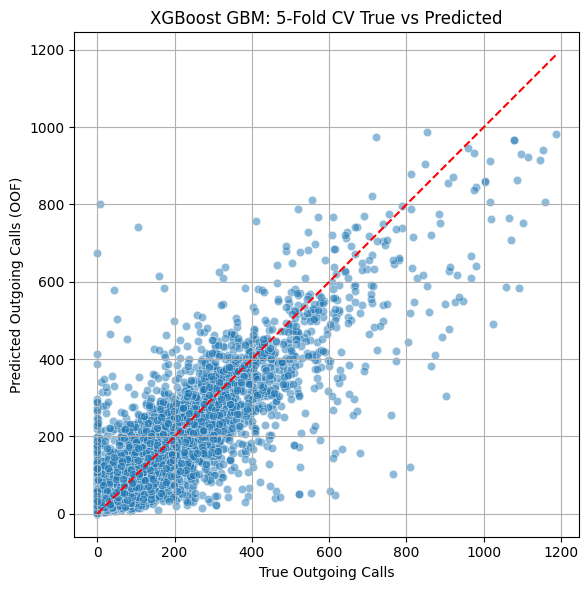

In [8]:
# 1. Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_predict
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load & Prepare the Data
train_data_encoded = pd.read_csv('../data/train_encoded.csv')
X = train_data_encoded.drop('y', axis=1)
y = train_data_encoded['y']

# Set your best found hyperparameters
best_est = int(500)      # found 500
best_depth = int(6)      # found 6
best_learn = 0.01        # found 0.01
best_sub = 0.7           # found 0.7
best_bytree = 1.0        # found 1.0

# 3. Set up 5-Fold CV and GBM Regressor model
cv = KFold(n_splits=5, shuffle=True, random_state=42)

gbm = XGBRegressor(
    n_estimators=best_est,
    max_depth=best_depth,
    learning_rate=best_learn,
    subsample=best_sub,
    colsample_bytree=best_bytree,
    random_state=42,
    n_jobs=-1
)

# 4. Obtain out-of-fold predictions
y_oof_pred = cross_val_predict(
    gbm, X, y,
    cv=cv,
    method='predict'
)

# 5. Evaluate OOF performance
mse = mean_squared_error(y, y_oof_pred)
r2 = r2_score(y, y_oof_pred)

print(f"5-Fold CV MSE: {mse:.2f}")
print(f"5-Fold CV R² Score: {r2:.4f}")

# 6. Visualize True vs Predicted
plt.figure(figsize=(6,6))
sns.scatterplot(x=y, y=y_oof_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("True Outgoing Calls")
plt.ylabel("Predicted Outgoing Calls (OOF)")
plt.title("XGBoost GBM: 5-Fold CV True vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()


In [7]:
# 7. Retrain on Full Data
gbm_full = XGBRegressor(
    n_estimators=best_est,
    max_depth=best_depth,
    learning_rate=best_learn,
    subsample=best_sub,
    colsample_bytree=best_bytree,
    random_state=42,
    n_jobs=-1
)
gbm_full.fit(X, y)

# 8. Predict on Test Set
test_data_encoded = pd.read_csv('../data/test_encoded.csv')
X_test = test_data_encoded.copy()

y_test_pred = gbm_full.predict(X_test)

# Optionally, clip negative predictions
y_test_pred = np.clip(y_test_pred, 0, None)

# 9. Save Final Predictions
np.savetxt('../prediction/predicted_GBM.txt', y_test_pred, fmt='%.6f')

print("\nPredictions saved to '../prediction/predicted_GBM.txt'.") # 38.48


Predictions saved to '../prediction/predicted_GBM.txt'.
